# TP Exploracion

**Estudiante:** LUDI, Noah  
**Datos:** Yellow Taxi y estación NOAA `USW00094728`, enero de 2024.

## Preparación de datos

Se usa el mes completo en hora local de Nueva York. Los viajes inválidos se separan antes de agregar los pickups por zona y hora.

In [1]:
from io import StringIO
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
MODO_CLASE = False
INICIO_MES = pd.Timestamp("2024-01-01")
FIN_MES = pd.Timestamp("2024-02-01")
FIN_ANALISIS = pd.Timestamp("2024-01-08") if MODO_CLASE else FIN_MES
ZONA_HORARIA = "America/New_York"

print(f"Ventana: {INICIO_MES} hasta {FIN_ANALISIS} (fin no incluido)")

Ventana: 2024-01-01 00:00:00 hasta 2024-02-01 00:00:00 (fin no incluido)


In [3]:
def construir_url_tlc(tipo, anio, mes):
    prefijos = {
        "yellow": "yellow_tripdata",
        "green": "green_tripdata",
        "fhv": "fhv_tripdata",
        "fhvhv": "fhvhv_tripdata",
    }
    if tipo not in prefijos:
        raise ValueError(f"tipo debe ser uno de: {', '.join(prefijos)}")
    if isinstance(anio, bool) or not isinstance(anio, (int, np.integer)) or not 2009 <= anio <= 2100:
        raise ValueError("anio debe ser un entero entre 2009 y 2100")
    if isinstance(mes, bool) or not isinstance(mes, (int, np.integer)) or not 1 <= mes <= 12:
        raise ValueError("mes debe ser un entero entre 1 y 12")
    archivo = f"{prefijos[tipo]}_{anio}-{mes:02d}.parquet"
    return f"https://d37ci6vzurychx.cloudfront.net/trip-data/{archivo}"

URL_VIAJES = construir_url_tlc("yellow", 2024, 1)
URL_ZONAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
URL_CLIMA = (
    "https://www.ncei.noaa.gov/oa/global-historical-climatology-network/"
    "hourly/access/by-year/2024/psv/GHCNh_USW00094728_2024.psv"
)
print(URL_VIAJES)

https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet


In [4]:
COLUMNAS_VIAJES = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "PULocationID",
    "DOLocationID", "fare_amount", "total_amount",
]
filtros = [
    ("tpep_pickup_datetime", ">=", INICIO_MES.to_pydatetime()),
    ("tpep_pickup_datetime", "<", FIN_ANALISIS.to_pydatetime()),
]

viajes_originales = pd.read_parquet(
    URL_VIAJES, columns=COLUMNAS_VIAJES, filters=filtros, engine="pyarrow"
)
print(f"Viajes cargados: {len(viajes_originales):,}")

Viajes cargados: 2,964,606


In [5]:
print("Shape:", viajes_originales.shape)
display(viajes_originales.head())
print("\nInfo:")
viajes_originales.info()
print("\nTipos:")
display(viajes_originales.dtypes.rename("dtype").to_frame())

faltantes = (
    viajes_originales.isna().sum().rename("n_faltantes").to_frame()
    .assign(porcentaje=lambda x: 100 * x["n_faltantes"] / len(viajes_originales))
    .sort_values("porcentaje", ascending=False)
)
display(faltantes)

Shape: (2964606, 8)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,186,79,17.7,22.70
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,140,236,10.0,18.75
2,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,236,79,23.3,31.30
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,79,211,10.0,17.00
4,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,211,148,7.9,16.10



Info:
<class 'pandas.DataFrame'>
RangeIndex: 2964606 entries, 0 to 2964605
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   PULocationID           int32         
 5   DOLocationID           int32         
 6   fare_amount            float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(4), int32(2)
memory usage: 158.3 MB

Tipos:


,dtype
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
PULocationID,int32
DOLocationID,int32
fare_amount,float64
total_amount,float64


,n_faltantes,porcentaje
passenger_count,140162,4.727846
tpep_pickup_datetime,0,0.000000
tpep_dropoff_datetime,0,0.000000
trip_distance,0,0.000000
PULocationID,0,0.000000
DOLocationID,0,0.000000
fare_amount,0,0.000000
total_amount,0,0.000000


Se consideran válidos viajes con fechas coherentes, duración entre 0 y 24 horas, distancia entre 0 y 100 millas, identificadores presentes, importes entre 0 y 1.000 dólares y hasta 8 pasajeros. Los pasajeros faltantes no invalidan el viaje.

In [6]:
calidad = viajes_originales.copy()
calidad["duracion_min"] = (
    calidad["tpep_dropoff_datetime"] - calidad["tpep_pickup_datetime"]
).dt.total_seconds() / 60

calidad["ok_pickup"] = calidad["tpep_pickup_datetime"].notna() & calidad["tpep_pickup_datetime"].between(INICIO_MES, FIN_ANALISIS, inclusive="left")
calidad["ok_dropoff"] = calidad["tpep_dropoff_datetime"].notna()
calidad["ok_duracion"] = calidad["duracion_min"].gt(0) & calidad["duracion_min"].le(24 * 60)
calidad["ok_distancia"] = calidad["trip_distance"].between(0, 100, inclusive="both")
calidad["ok_id_pickup_presente"] = calidad["PULocationID"].notna()
calidad["ok_id_dropoff_presente"] = calidad["DOLocationID"].notna()
calidad["ok_importes"] = (
    calidad["fare_amount"].between(0, 1_000, inclusive="both")
    & calidad["total_amount"].between(0, 1_000, inclusive="both")
    & calidad["total_amount"].ge(calidad["fare_amount"])
)
calidad["ok_pasajeros"] = calidad["passenger_count"].isna() | calidad["passenger_count"].between(0, 8, inclusive="both")

REGLAS = [c for c in calidad.columns if c.startswith("ok_")]
calidad["registro_valido"] = calidad[REGLAS].all(axis=1)
auditoria = pd.DataFrame({
    "regla": REGLAS,
    "cumplen": [int(calidad[c].sum()) for c in REGLAS],
    "incumplen": [int((~calidad[c]).sum()) for c in REGLAS],
})
auditoria["porcentaje_incumple"] = 100 * auditoria["incumplen"] / len(calidad)
display(auditoria.sort_values("porcentaje_incumple", ascending=False))

,regla,cumplen,incumplen,porcentaje_incumple
6,ok_importes,2927032,37574,1.267420
2,ok_duracion,2963720,886,0.029886
3,ok_distancia,2964547,59,0.001990
7,ok_pasajeros,2964605,1,0.000034
0,ok_pickup,2964606,0,0.000000
1,ok_dropoff,2964606,0,0.000000
5,ok_id_dropoff_presente,2964606,0,0.000000
4,ok_id_pickup_presente,2964606,0,0.000000


In [7]:
viajes_rechazados = calidad.loc[~calidad["registro_valido"]].copy()
viajes_validos = calidad.loc[calidad["registro_valido"]].copy()
print(f"Válidos: {len(viajes_validos):,} | Rechazados: {len(viajes_rechazados):,}")
display(viajes_rechazados[COLUMNAS_VIAJES + ["duracion_min"] + REGLAS].head())

Válidos: 2,926,101 | Rechazados: 38,505


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount,duracion_min,ok_pickup,ok_dropoff,ok_duracion,ok_distancia,ok_id_pickup_presente,ok_id_dropoff_presente,ok_importes,ok_pasajeros
23,2024-01-01 00:14:29,2024-01-01 00:14:29,1.0,0.00,236,264,3.0,8.00,0.000000,True,True,False,True,True,True,True,True
99,2024-01-01 00:18:24,2024-01-01 00:30:39,1.0,2.16,249,232,-13.5,-18.50,12.250000,True,True,True,True,True,True,False,True
504,2024-01-01 00:04:00,2024-01-01 00:04:44,1.0,0.01,63,63,-31.5,-34.25,0.733333,True,True,True,True,True,True,False,True
534,2024-01-01 00:41:42,2024-01-01 00:46:00,1.0,0.47,249,113,-5.8,-10.80,4.300000,True,True,True,True,True,True,False,True
550,2024-01-01 00:42:02,2024-01-01 01:14:33,1.0,5.48,107,61,-33.1,-38.10,32.516667,True,True,True,True,True,True,False,True


## Zonas, horas y clima

In [8]:
zonas = pd.read_csv(URL_ZONAS)
display(zonas.head())
print("Cantidad de zonas:", len(zonas))
print("LocationID es único:", zonas["LocationID"].is_unique)

if zonas["LocationID"].duplicated().any():
    raise ValueError("Taxi Zone Lookup contiene LocationID duplicados")

zonas_pickup = zonas.rename(columns={
    "LocationID": "PULocationID", "Borough": "pickup_borough",
    "Zone": "pickup_zone", "service_zone": "pickup_service_zone",
})
zonas_dropoff = zonas.rename(columns={
    "LocationID": "DOLocationID", "Borough": "dropoff_borough",
    "Zone": "dropoff_zone", "service_zone": "dropoff_service_zone",
})

display(zonas_pickup.head(2))
display(zonas_dropoff.head(2))

viajes_zonas = (
    viajes_validos.merge(zonas_pickup, on="PULocationID", how="left", validate="many_to_one")
    .merge(zonas_dropoff, on="DOLocationID", how="left", validate="many_to_one")
)

assert len(viajes_zonas) == len(viajes_validos), "La unión cambió el número de viajes"

sin_nombre_pickup = viajes_zonas["pickup_zone"].isna().sum()
sin_nombre_dropoff = viajes_zonas["dropoff_zone"].isna().sum()
print("Viajes antes y después:", len(viajes_validos), len(viajes_zonas))
print("Sin zona pickup:", sin_nombre_pickup, "| Sin zona dropoff:", sin_nombre_dropoff)

COLUMNAS_ZONA = [
    "PULocationID", "pickup_borough", "pickup_zone", "pickup_service_zone",
    "DOLocationID", "dropoff_borough", "dropoff_zone", "dropoff_service_zone",
]
display(viajes_zonas[COLUMNAS_ZONA].head())

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Cantidad de zonas: 265
LocationID es único: True


,PULocationID,pickup_borough,pickup_zone,pickup_service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone


,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone


Viajes antes y después: 2926101 2926101
Sin zona pickup: 10177 | Sin zona dropoff: 15295


,PULocationID,pickup_borough,pickup_zone,pickup_service_zone,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone
0,186,Manhattan,Penn Station/Madison Sq West,Yellow Zone,79,Manhattan,East Village,Yellow Zone
1,140,Manhattan,Lenox Hill East,Yellow Zone,236,Manhattan,Upper East Side North,Yellow Zone
2,236,Manhattan,Upper East Side North,Yellow Zone,79,Manhattan,East Village,Yellow Zone
3,79,Manhattan,East Village,Yellow Zone,211,Manhattan,SoHo,Yellow Zone
4,211,Manhattan,SoHo,Yellow Zone,148,Manhattan,Lower East Side,Yellow Zone


In [9]:
viajes_zonas["pickup_hora"] = (
    viajes_zonas["tpep_pickup_datetime"]
    .dt.tz_localize(ZONA_HORARIA, ambiguous="raise", nonexistent="raise")
    .dt.floor("h")
)
pickups_zona_hora = (
    viajes_zonas.groupby(
        ["pickup_hora", "PULocationID", "pickup_borough", "pickup_zone"],
        observed=True, dropna=False,
    )
    .size().rename("pickups").reset_index()
)
assert pickups_zona_hora.duplicated(["pickup_hora", "PULocationID"]).sum() == 0
display(pickups_zona_hora.head())

,pickup_hora,PULocationID,pickup_borough,pickup_zone,pickups
0,2024-01-01 00:00:00-05:00,4,Manhattan,Alphabet City,24
1,2024-01-01 00:00:00-05:00,7,Queens,Astoria,4
2,2024-01-01 00:00:00-05:00,9,Queens,Auburndale,1
3,2024-01-01 00:00:00-05:00,10,Queens,Baisley Park,6
4,2024-01-01 00:00:00-05:00,12,Manhattan,Battery Park,4


In [10]:
COLUMNAS_CLIMA = [
    "STATION", "Station_name", "DATE", "temperature",
    "relative_humidity", "wind_speed", "visibility",
]
with urlopen(URL_CLIMA) as respuesta:
    texto_clima = respuesta.read().decode("utf-8")
clima_bruto = pd.read_csv(StringIO(texto_clima), sep="|", usecols=COLUMNAS_CLIMA, low_memory=False)
assert clima_bruto["STATION"].astype(str).eq("USW00094728").all()
print("Observaciones meteorológicas cargadas:", len(clima_bruto))

clima = clima_bruto.copy()
clima["fecha_utc"] = pd.to_datetime(clima["DATE"], utc=True, errors="coerce")
clima["fecha_ny"] = clima["fecha_utc"].dt.tz_convert(ZONA_HORARIA)
inicio_local = INICIO_MES.tz_localize(ZONA_HORARIA)
fin_local = FIN_ANALISIS.tz_localize(ZONA_HORARIA)
clima = clima.loc[clima["fecha_ny"].between(inicio_local, fin_local, inclusive="left")].copy()

VARIABLES_CLIMA = ["temperature", "relative_humidity", "wind_speed", "visibility"]
clima[VARIABLES_CLIMA] = clima[VARIABLES_CLIMA].apply(pd.to_numeric, errors="coerce")
clima["hora"] = clima["fecha_ny"].dt.floor("h")
clima_horario = (
    clima.groupby("hora", as_index=False)
    .agg(
        temperatura_c=("temperature", "mean"),
        humedad_relativa=("relative_humidity", "mean"),
        viento=("wind_speed", "mean"),
        visibilidad=("visibility", "mean"),
        observaciones=("fecha_ny", "size"),
    )
)
if clima_horario["hora"].duplicated().any():
    raise ValueError("El resumen climático no es único por hora")
display(clima_horario.head())

horas_esperadas_clima = pd.date_range(
    inicio_local, fin_local, freq="h", inclusive="left"
)
horas_sin_clima = horas_esperadas_clima.difference(clima_horario["hora"])
print("Horas esperadas:", len(horas_esperadas_clima))
print("Horas observadas:", clima_horario["hora"].nunique())
print("Horas sin clima:", len(horas_sin_clima))
display(horas_sin_clima.to_frame(index=False, name="hora_sin_clima"))

Observaciones meteorológicas cargadas: 11222


,hora,temperatura_c,humedad_relativa,viento,visibilidad,observaciones
0,2024-01-01 00:00:00-05:00,5.6,55.0,3.1,16.093,1
1,2024-01-01 01:00:00-05:00,5.6,58.0,2.1,16.093,1
2,2024-01-01 02:00:00-05:00,5.0,60.0,0.0,16.093,1
3,2024-01-01 03:00:00-05:00,5.0,62.0,1.5,16.093,1
4,2024-01-01 04:00:00-05:00,4.4,68.0,0.0,16.093,1


Horas esperadas: 744
Horas observadas: 743
Horas sin clima: 1


,hora_sin_clima
0,2024-01-10 11:00:00-05:00


In [11]:
zona_hora_clima = pickups_zona_hora.merge(
    clima_horario, left_on="pickup_hora", right_on="hora",
    how="left", validate="many_to_one", indicator=True,
)
assert len(zona_hora_clima) == len(pickups_zona_hora)
display(zona_hora_clima["_merge"].value_counts(dropna=False).rename_axis("resultado").to_frame("filas"))
producto = (
    zona_hora_clima.drop(columns="_merge")
    .sort_values(["pickup_hora", "PULocationID"])
    .copy()
)
assert not producto.duplicated(["pickup_hora", "PULocationID"]).any()

,filas
resultado,
both,77335
left_only,131
right_only,0


# Trabajo práctico: exploración de dos variables

## Contrato del análisis

| Campo | Definición |
|---|---|
| Código y par | PC-01: `pickups` y `temperatura_c` |
| Pregunta | ¿Cómo varían los pickups por hora junto con la temperatura durante enero de 2024? |
| Significado | Pickups válidos por hora y temperatura media horaria en °C |
| Tipos | `pickups`: cuantitativa discreta; `temperatura_c`: cuantitativa continua |
| Vista y unidad | H: una hora local |
| Periodo | `[2024-01-01, 2024-02-01)` en `America/New_York` |
| Población | Viajes Yellow Taxi reportados que pasaron las reglas de calidad y mediciones de una estación NOAA |
| Denominador | Hasta 744 horas; la relación usa solo pares completos |
| Alcance | No representa demanda total, todos los taxis ni el clima de toda la ciudad; tampoco permite afirmar causalidad |
| Sensibilidad prevista | Comparar Pearson y Spearman, con y sin candidatos Tukey, y separar por hora del día |

In [12]:
assert MODO_CLASE is False, "El TP requiere enero completo"
assert INICIO_MES == pd.Timestamp("2024-01-01")
assert FIN_ANALISIS == pd.Timestamp("2024-02-01")
assert ZONA_HORARIA == "America/New_York"
assert not producto.duplicated(["pickup_hora", "PULocationID"]).any()
print("Preparación del TP: OK")

Preparación del TP: OK


## Vista H

Los pickups se suman entre zonas. El clima se conserva una sola vez por hora después de comprobar que no cambia entre las zonas. Los faltantes se mantienen como `NaN`.

In [13]:
VARIABLES_NOAA_TP = [
    "temperatura_c",
    "humedad_relativa",
    "viento",
    "visibilidad",
]

consistencia_noaa = (
    producto.groupby("pickup_hora")[VARIABLES_NOAA_TP]
    .nunique(dropna=False)
)
if not consistencia_noaa.le(1).all().all():
    raise ValueError("Una misma hora contiene valores NOAA diferentes entre zonas")

por_hora = producto.groupby("pickup_hora", as_index=False).agg(
    pickups=("pickups", "sum"),
    temperatura_c=("temperatura_c", "first"),
    humedad_relativa=("humedad_relativa", "first"),
    viento=("viento", "first"),
    visibilidad=("visibilidad", "first"),
)
assert not por_hora["pickup_hora"].duplicated().any()

horas_esperadas = pd.date_range(
    INICIO_MES.tz_localize(ZONA_HORARIA),
    FIN_MES.tz_localize(ZONA_HORARIA),
    freq="h",
    inclusive="left",
)
horas_observadas = pd.DatetimeIndex(por_hora["pickup_hora"].dropna().unique()).sort_values()
horas_ausentes = horas_esperadas.difference(horas_observadas)

cobertura_horaria = pd.DataFrame({
    "horas_esperadas": [len(horas_esperadas)],
    "horas_observadas": [len(horas_observadas)],
    "horas_ausentes": [len(horas_ausentes)],
    "temperatura_valida": [por_hora["temperatura_c"].notna().sum()],
    "temperatura_faltante": [por_hora["temperatura_c"].isna().sum()],
})
display(cobertura_horaria)
display(por_hora.head())

,horas_esperadas,horas_observadas,horas_ausentes,temperatura_valida,temperatura_faltante
0,744,744,0,743,1


,pickup_hora,pickups,temperatura_c,humedad_relativa,viento,visibilidad
0,2024-01-01 00:00:00-05:00,6513,5.6,55.0,3.1,16.093
1,2024-01-01 01:00:00-05:00,7249,5.6,58.0,2.1,16.093
2,2024-01-01 02:00:00-05:00,6111,5.0,60.0,0.0,16.093
3,2024-01-01 03:00:00-05:00,4857,5.0,62.0,1.5,16.093
4,2024-01-01 04:00:00-05:00,3128,4.4,68.0,0.0,16.093


## Análisis individual

`pickups` es la suma horaria de viajes reportados y `temperatura_c` es la media de observaciones NOAA dentro de cada hora.

In [14]:
COLUMNAS_ANALISIS = ["pickups", "temperatura_c"]

cobertura_variables = pd.DataFrame({
    "variable": COLUMNAS_ANALISIS,
    "tipo_fisico": [str(por_hora[c].dtype) for c in COLUMNAS_ANALISIS],
    "tipo_semantico": ["cuantitativa discreta", "cuantitativa continua"],
    "filas_totales": [len(por_hora)] * 2,
    "validos": [por_hora[c].notna().sum() for c in COLUMNAS_ANALISIS],
    "faltantes": [por_hora[c].isna().sum() for c in COLUMNAS_ANALISIS],
    "ceros": [por_hora[c].eq(0).sum() for c in COLUMNAS_ANALISIS],
    "unicos": [por_hora[c].nunique(dropna=True) for c in COLUMNAS_ANALISIS],
    "agregacion": [
        "suma de pickups entre zonas por hora",
        "media NOAA subhoraria y first entre zonas",
    ],
})

def resumen_numerico(serie):
    valida = serie.dropna()
    q1, mediana, q3 = valida.quantile([0.25, 0.50, 0.75])
    return pd.Series({
        "n_valido": len(valida),
        "minimo": valida.min(),
        "q1": q1,
        "mediana": mediana,
        "media": valida.mean(),
        "q3": q3,
        "maximo": valida.max(),
        "iqr": q3 - q1,
        "desviacion_estandar": valida.std(),
        "porcentaje_ceros_validos": 100 * valida.eq(0).mean(),
    })

resumen_distribucion = pd.DataFrame({
    columna: resumen_numerico(por_hora[columna])
    for columna in COLUMNAS_ANALISIS
}).T

display(cobertura_variables)
display(resumen_distribucion.round(3))

,variable,tipo_fisico,tipo_semantico,filas_totales,validos,faltantes,ceros,unicos,agregacion
0,pickups,int64,cuantitativa discreta,744,744,0,0,705,suma de pickups entre zonas por hora
1,temperatura_c,float64,cuantitativa continua,744,743,1,18,136,media NOAA subhoraria y first entre zonas


,n_valido,minimo,q1,mediana,media,q3,maximo,iqr,desviacion_estandar,porcentaje_ceros_validos
pickups,744.0,152.0,1592.25,4519.0,3932.931,5719.25,9027.0,4127.0,2275.768,0.000
temperatura_c,743.0,-8.3,-0.60,2.8,2.736,6.10,15.2,6.7,4.763,2.423


### Pickups

El histograma muestra la distribución y el boxplot resume mediana, dispersión y extremos. Los intervalos se calculan con la regla de Freedman-Diaconis.

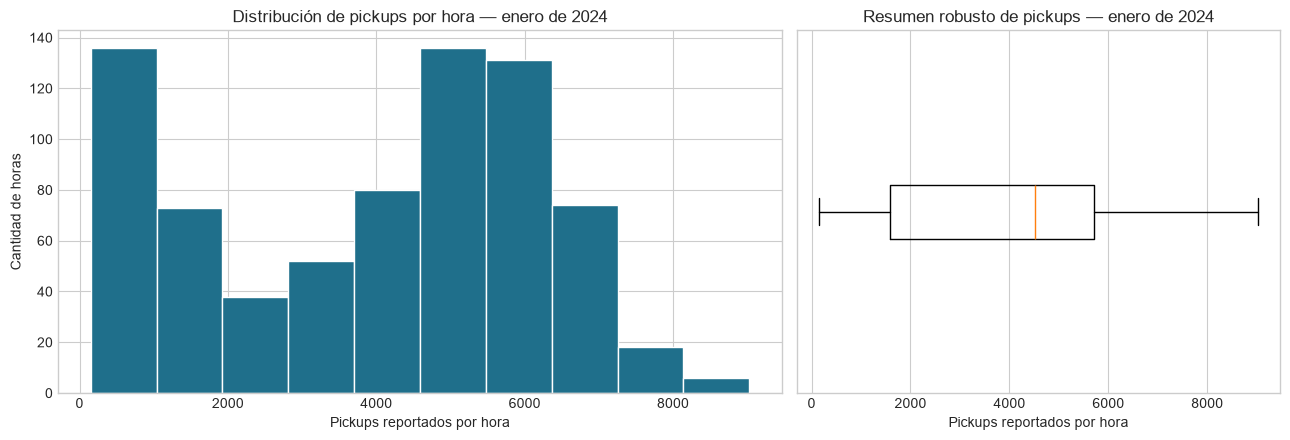

Freedman–Diaconis: 10 intervalos; ancho aproximado = 910.9 pickups.


In [15]:
def intervalos_freedman_diaconis(serie):
    valida = serie.dropna()
    q1, q3 = valida.quantile([0.25, 0.75])
    ancho = 2 * (q3 - q1) / np.cbrt(len(valida))
    cantidad = int(np.ceil((valida.max() - valida.min()) / ancho)) if ancho > 0 else 1
    return max(cantidad, 1), ancho

bins_pickups, ancho_pickups = intervalos_freedman_diaconis(por_hora["pickups"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [3, 2]})
axes[0].hist(por_hora["pickups"], bins=bins_pickups, color="#1f6f8b", edgecolor="white")
axes[0].set(
    title="Distribución de pickups por hora — enero de 2024",
    xlabel="Pickups reportados por hora", ylabel="Cantidad de horas",
)
axes[1].boxplot(por_hora["pickups"].dropna(), orientation="horizontal")
axes[1].set(
    title="Resumen robusto de pickups — enero de 2024",
    xlabel="Pickups reportados por hora", yticks=[],
)
plt.tight_layout()
plt.show()
print(f"Freedman–Diaconis: {bins_pickups} intervalos; ancho aproximado = {ancho_pickups:.1f} pickups.")

Las 744 horas tienen datos y ninguna vale cero. La mediana es 4.519 pickups y el IQR va de 1.592,25 a 5.719,25. La variación también depende de los horarios y del calendario.

### Temperatura

Se usan el mismo criterio de intervalos y un boxplot. Cero grados es un valor válido, no un faltante.

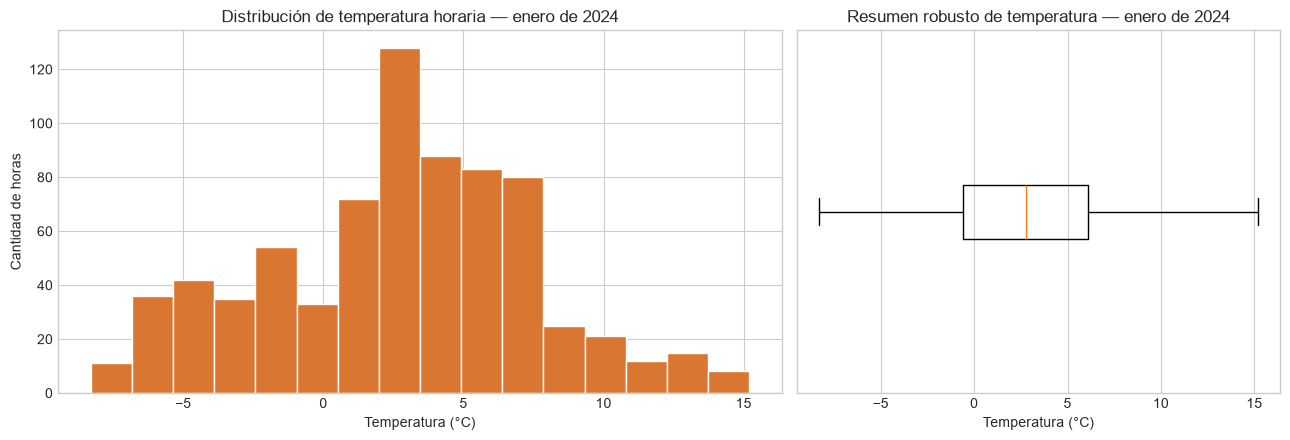

Freedman–Diaconis: 16 intervalos; ancho aproximado = 1.48 °C.


In [16]:
bins_temp, ancho_temp = intervalos_freedman_diaconis(por_hora["temperatura_c"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [3, 2]})
axes[0].hist(
    por_hora["temperatura_c"].dropna(), bins=bins_temp,
    color="#d97732", edgecolor="white",
)
axes[0].set(
    title="Distribución de temperatura horaria — enero de 2024",
    xlabel="Temperatura (°C)", ylabel="Cantidad de horas",
)
axes[1].boxplot(por_hora["temperatura_c"].dropna(), orientation="horizontal")
axes[1].set(
    title="Resumen robusto de temperatura — enero de 2024",
    xlabel="Temperatura (°C)", yticks=[],
)
plt.tight_layout()
plt.show()
print(f"Freedman–Diaconis: {bins_temp} intervalos; ancho aproximado = {ancho_temp:.2f} °C.")

Hay 743 horas válidas y una faltante. La mediana es 2,8 °C, el IQR va de -0,6 a 6,1 °C y el rango observado es posible para enero.

## Casos potencialmente anómalos

Se aplica la regla de Tukey: valores fuera de `Q1 - 1,5 IQR` y `Q3 + 1,5 IQR`. Son casos para revisar, no errores automáticos.

In [17]:
limites_tukey = []
banderas_tukey = pd.DataFrame(False, index=por_hora.index, columns=COLUMNAS_ANALISIS)
for columna in COLUMNAS_ANALISIS:
    valida = por_hora[columna].dropna()
    q1, q3 = valida.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    banderas_tukey[columna] = (
        por_hora[columna].lt(limite_inferior)
        | por_hora[columna].gt(limite_superior)
    )
    limites_tukey.append({
        "variable": columna, "q1": q1, "q3": q3, "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "candidatos": int(banderas_tukey[columna].sum()),
    })
limites_tukey = pd.DataFrame(limites_tukey)

contexto_horario = por_hora.assign(
    fecha=por_hora["pickup_hora"].dt.date,
    hora_dia=por_hora["pickup_hora"].dt.hour,
    dia_semana=por_hora["pickup_hora"].dt.day_name(),
    candidato_pickups=banderas_tukey["pickups"],
    candidato_temperatura=banderas_tukey["temperatura_c"],
)
casos_tukey = contexto_horario.loc[banderas_tukey.any(axis=1)].copy()
horas_temperatura_faltante = contexto_horario.loc[
    contexto_horario["temperatura_c"].isna(),
    ["pickup_hora", "pickups", "temperatura_c", "dia_semana", "hora_dia"],
]

extremos_revisados = []
for columna in COLUMNAS_ANALISIS:
    for extremo, indice in [("mínimo", por_hora[columna].idxmin()), ("máximo", por_hora[columna].idxmax())]:
        fila = contexto_horario.loc[indice]
        extremos_revisados.append({
            "variable": columna, "extremo": extremo, "valor": fila[columna],
            "pickup_hora": fila["pickup_hora"], "dia_semana": fila["dia_semana"],
            "hora_dia": fila["hora_dia"], "señalado_por_tukey": banderas_tukey.loc[indice, columna],
        })
extremos_revisados = pd.DataFrame(extremos_revisados)

comparacion_con_sin = []
for columna in COLUMNAS_ANALISIS:
    for escenario, mascara in [
        ("todos los valores válidos", por_hora[columna].notna()),
        ("sin candidatos Tukey", por_hora[columna].notna() & ~banderas_tukey[columna]),
    ]:
        valores = por_hora.loc[mascara, columna]
        comparacion_con_sin.append({
            "variable": columna, "escenario": escenario, "n": len(valores),
            "media": valores.mean(), "mediana": valores.median(), "desviacion": valores.std(),
        })
comparacion_con_sin = pd.DataFrame(comparacion_con_sin)

display(limites_tukey.round(3))
display(casos_tukey if not casos_tukey.empty else pd.DataFrame(columns=contexto_horario.columns))
display(extremos_revisados)
display(horas_temperatura_faltante)
display(comparacion_con_sin.round(3))

,variable,q1,q3,iqr,limite_inferior,limite_superior,candidatos
0,pickups,1592.25,5719.25,4127.0,-4598.25,11909.75,0
1,temperatura_c,-0.60,6.10,6.7,-10.65,16.15,0


,pickup_hora,pickups,temperatura_c,humedad_relativa,viento,visibilidad,fecha,hora_dia,dia_semana,candidato_pickups,candidato_temperatura


,variable,extremo,valor,pickup_hora,dia_semana,hora_dia,señalado_por_tukey
0,pickups,mínimo,152.0,2024-01-30 03:00:00-05:00,Tuesday,3,False
1,pickups,máximo,9027.0,2024-01-17 18:00:00-05:00,Wednesday,18,False
2,temperatura_c,mínimo,-8.3,2024-01-17 07:00:00-05:00,Wednesday,7,False
3,temperatura_c,máximo,15.2,2024-01-13 09:00:00-05:00,Saturday,9,False


,pickup_hora,pickups,temperatura_c,dia_semana,hora_dia
227,2024-01-10 11:00:00-05:00,4843,NaN,Wednesday,11


,variable,escenario,n,media,mediana,desviacion
0,pickups,todos los valores válidos,744,3932.931,4519.0,2275.768
1,pickups,sin candidatos Tukey,744,3932.931,4519.0,2275.768
2,temperatura_c,todos los valores válidos,743,2.736,2.8,4.763
3,temperatura_c,sin candidatos Tukey,743,2.736,2.8,4.763


Tukey no detectó candidatos y los extremos no violan el dominio esperado, por lo que no se elimina ningún valor. La temperatura faltante se conserva como `NaN` y queda fuera solamente de los cálculos que requieren ambas columnas.

## Relación entre pickups y temperatura

El gráfico permite ver dirección, dispersión y puntos influyentes. Pearson mide asociación lineal y Spearman asociación monotónica.

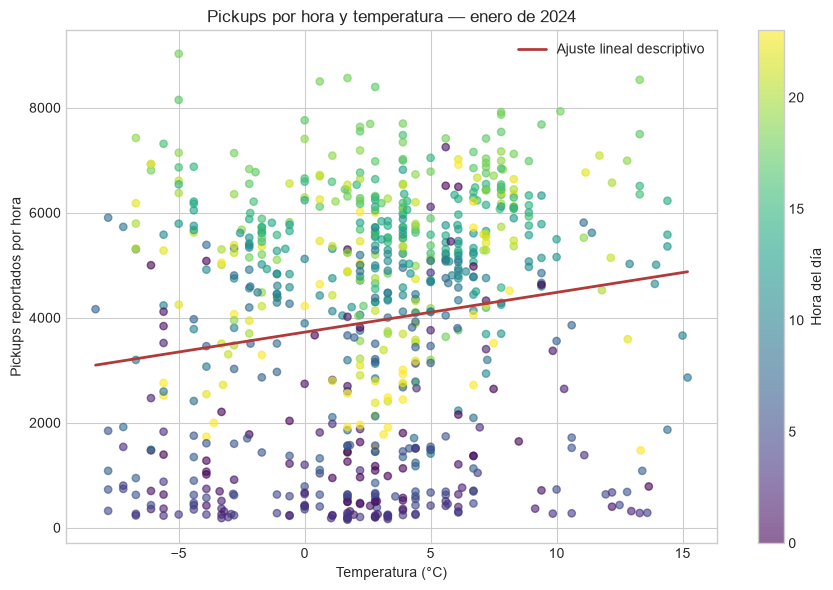

,escenario,n,Pearson,Spearman
0,todos los pares válidos,743,0.158,0.184
1,sin candidatos Tukey,743,0.158,0.184


,pickup_hora,pickups,temperatura_c,cambio_abs_Pearson,cambio_abs_Spearman
220,2024-01-10 04:00:00-05:00,284,13.600000,0.0058,0.0042
401,2024-01-17 18:00:00-05:00,9027,-5.000000,0.0058,0.0042
219,2024-01-10 03:00:00-05:00,280,13.300000,0.0056,0.0041
218,2024-01-10 02:00:00-05:00,316,12.966667,0.0054,0.0040
593,2024-01-25 18:00:00-05:00,8531,13.300000,0.0051,0.0031


In [18]:
pares_validos = por_hora.dropna(subset=COLUMNAS_ANALISIS).copy()
pearson = pares_validos["pickups"].corr(pares_validos["temperatura_c"], method="pearson")
spearman = pares_validos["pickups"].corr(pares_validos["temperatura_c"], method="spearman")
mascara_sin_tukey = ~banderas_tukey.any(axis=1) & por_hora[COLUMNAS_ANALISIS].notna().all(axis=1)
pares_sin_tukey = por_hora.loc[mascara_sin_tukey, COLUMNAS_ANALISIS]
correlaciones = pd.DataFrame([
    {"escenario": "todos los pares válidos", "n": len(pares_validos), "Pearson": pearson, "Spearman": spearman},
    {
        "escenario": "sin candidatos Tukey", "n": len(pares_sin_tukey),
        "Pearson": pares_sin_tukey["pickups"].corr(pares_sin_tukey["temperatura_c"], method="pearson"),
        "Spearman": pares_sin_tukey["pickups"].corr(pares_sin_tukey["temperatura_c"], method="spearman"),
    },
])

influencia_individual = []
for indice, fila in pares_validos.iterrows():
    sin_fila = pares_validos.drop(index=indice)
    influencia_individual.append({
        "pickup_hora": fila["pickup_hora"],
        "pickups": fila["pickups"],
        "temperatura_c": fila["temperatura_c"],
        "cambio_abs_Pearson": abs(sin_fila["pickups"].corr(sin_fila["temperatura_c"], method="pearson") - pearson),
        "cambio_abs_Spearman": abs(sin_fila["pickups"].corr(sin_fila["temperatura_c"], method="spearman") - spearman),
    })
influencia_individual = (
    pd.DataFrame(influencia_individual)
    .sort_values("cambio_abs_Pearson", ascending=False)
)

pendiente, intercepto = np.polyfit(pares_validos["temperatura_c"], pares_validos["pickups"], 1)
x_linea = np.linspace(pares_validos["temperatura_c"].min(), pares_validos["temperatura_c"].max(), 100)
fig, ax = plt.subplots(figsize=(9, 6))
dispersion = ax.scatter(
    pares_validos["temperatura_c"], pares_validos["pickups"],
    c=pares_validos["pickup_hora"].dt.hour, cmap="viridis", alpha=0.60, s=28,
)
ax.plot(x_linea, intercepto + pendiente * x_linea, color="#b33a3a", linewidth=2, label="Ajuste lineal descriptivo")
ax.set(
    title="Pickups por hora y temperatura — enero de 2024",
    xlabel="Temperatura (°C)", ylabel="Pickups reportados por hora",
)
fig.colorbar(dispersion, ax=ax, label="Hora del día")
ax.legend()
plt.tight_layout()
plt.show()
display(correlaciones.round(3))
influencia_mostrar = influencia_individual.head(5).copy()
columnas_cambio = ["cambio_abs_Pearson", "cambio_abs_Spearman"]
influencia_mostrar[columnas_cambio] = influencia_mostrar[columnas_cambio].round(4)
display(influencia_mostrar)

La nube es amplia, sin curvatura clara y con valores repetidos de temperatura. Pearson da 0,158 y Spearman 0,184: la asociación es positiva pero débil. Ninguna hora individual cambia de forma importante el resultado y el horario del día puede estar confundiendo la relación.

## Sensibilidad

Se repite la correlación por hora del día para comparar momentos similares del ciclo diario.

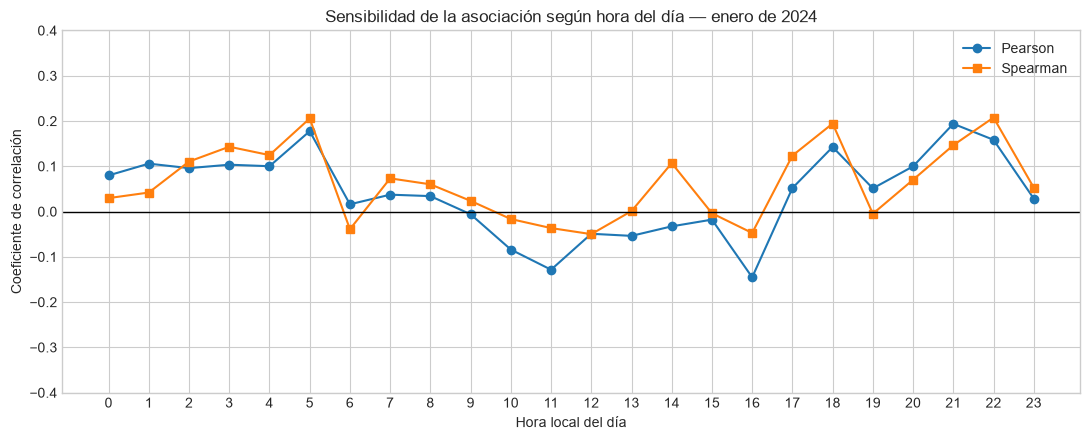

,hora_dia,n,Pearson,Spearman
0,0,31,0.080,0.030
1,1,31,0.106,0.042
2,2,31,0.096,0.110
3,3,31,0.103,0.143
4,4,31,0.100,0.125
5,5,31,0.177,0.206
6,6,31,0.016,-0.039
7,7,31,0.037,0.073
8,8,31,0.034,0.060
9,9,31,-0.006,0.024


In [19]:
pares_validos["hora_dia"] = pares_validos["pickup_hora"].dt.hour
correlacion_por_hora = []
for hora_dia, grupo in pares_validos.groupby("hora_dia"):
    correlacion_por_hora.append({
        "hora_dia": hora_dia, "n": len(grupo),
        "Pearson": grupo["pickups"].corr(grupo["temperatura_c"], method="pearson"),
        "Spearman": grupo["pickups"].corr(grupo["temperatura_c"], method="spearman"),
    })
correlacion_por_hora = pd.DataFrame(correlacion_por_hora)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(correlacion_por_hora["hora_dia"], correlacion_por_hora["Pearson"], marker="o", label="Pearson")
ax.plot(correlacion_por_hora["hora_dia"], correlacion_por_hora["Spearman"], marker="s", label="Spearman")
ax.axhline(0, color="black", linewidth=1)
ax.set(
    title="Sensibilidad de la asociación según hora del día — enero de 2024",
    xlabel="Hora local del día", ylabel="Coeficiente de correlación",
    xticks=range(24), ylim=(-0.4, 0.4),
)
ax.legend()
plt.tight_layout()
plt.show()
display(correlacion_por_hora.round(3))

Dentro de cada hora los coeficientes son pequeños y cambian de signo. La asociación mensual es débil y depende de la estructura horaria; además, cada grupo tiene solo 30 o 31 días.

## Hallazgos finales

**1. Pickups.** En las 744 horas de enero, la mediana fue 4.519 y el IQR 1.592,25-5.719,25, sin faltantes ni ceros. Se observa un ciclo horario amplio, aunque calendario, eventos y oferta de taxis también pueden influir. Estos viajes no representan demanda total. Como siguiente paso se podrían comparar días hábiles, fines de semana y feriados.

**2. Temperatura.** La estación NOAA aportó 743 de 744 horas. La mediana fue 2,8 °C, el IQR -0,6-6,1 °C y el rango -8,3-15,2 °C. Los valores son posibles, pero una estación no representa toda la ciudad y el promedio oculta cambios dentro de la hora. Se podría contrastar con estaciones cercanas.

**3. Relación.** Sobre 743 pares completos, Pearson fue 0,158 y Spearman 0,184. La asociación observada es positiva y débil, pero cambia al separar por hora. Hora pico, calendario, eventos y disponibilidad pueden explicar parte del patrón. No se puede afirmar causalidad y las horas consecutivas no son independientes. Conviene repetir el análisis en otros meses.

## Control de entrega

- [x] Identificación, par y vista
- [x] Enero completo y ejecución reproducible
- [x] Vista H validada
- [x] Dos análisis individuales y tres visualizaciones interpretadas
- [x] Anomalías, relación y sensibilidad
- [x] Tres hallazgos con límites y próximos pasos